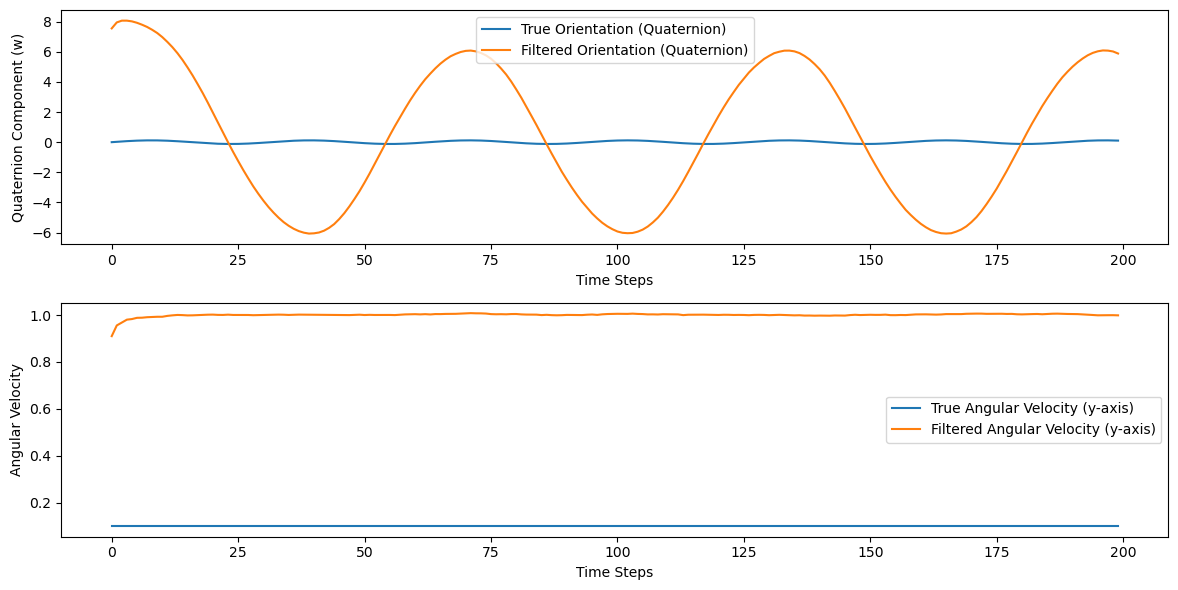

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def kalman_filter(acc, gyro, mag, dt):
    # Kalman filter parameters
    A = np.eye(6)  # State transition matrix
    H = np.eye(6)  # Measurement matrix
    Q = np.eye(6) * 0.001  # Process noise covariance
    R = np.eye(6) * 0.1  # Measurement noise covariance

    # Initialize the state and covariance
    x_hat = np.zeros(6)  # Initial state: [roll, pitch, yaw, roll_rate, pitch_rate, yaw_rate]
    P = np.eye(6)  # Initial covariance matrix

    # Lists to store filter output for plotting
    filtered_states = []

    for i in range(len(acc)):
        # Prediction step using gyroscope measurements
        x_hat_minus = np.dot(A, x_hat) + np.array([0, 0, 0, gyro[i, 0], gyro[i, 1], gyro[i, 2]]) * dt
        P_minus = np.dot(np.dot(A, P), A.T) + Q

        # Update step
        K = np.dot(np.dot(P_minus, H.T), np.linalg.inv(np.dot(np.dot(H, P_minus), H.T) + R))
        z = np.hstack([acc[i], mag[i]])
        y = z - np.dot(H, x_hat_minus)
        x_hat = x_hat_minus + np.dot(K, y)
        P = np.dot((np.eye(6) - np.dot(K, H)), P_minus)

        # Save results for plotting
        filtered_states.append(x_hat)

    return np.array(filtered_states)

# Simulate IMU measurements
np.random.seed(42)
num_samples = 200
time = np.arange(0, num_samples)
dt = 0.01  # Time step

# Generate true motion
true_orientation = R.from_euler('zyx', np.vstack([np.sin(0.1 * time), np.cos(0.1 * time), np.zeros(num_samples)]).T).as_quat()
true_angular_velocity = np.vstack([np.zeros(num_samples), 0.1 * np.ones(num_samples), np.zeros(num_samples)]).T
true_magnetic_field = np.vstack([np.ones(num_samples), np.zeros(num_samples), np.zeros(num_samples)]).T

# Simulate sensor measurements (including noise)
acceleration = np.array([R.from_quat(true_orientation[i]).apply([0, 0, 9.8]) + np.random.normal(0, 0.1, 3) for i in range(num_samples)])
gyro_rate = true_angular_velocity + np.random.normal(0, 0.01, (num_samples, 3))
mag_field = true_magnetic_field + np.random.normal(0, 0.01, (num_samples, 3))

# Run Kalman filter
filtered_states = kalman_filter(acceleration, gyro_rate, mag_field, dt)

# Extract orientation from the filtered states
filtered_orientation = filtered_states[:, :3]

# Plot results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time, true_orientation[:, 0], label="True Orientation (Quaternion)")
plt.plot(time, filtered_orientation[:, 0], label="Filtered Orientation (Quaternion)")
plt.xlabel("Time Steps")
plt.ylabel("Quaternion Component (w)")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time, true_angular_velocity[:, 1], label="True Angular Velocity (y-axis)")
plt.plot(time, filtered_states[:, 3], label="Filtered Angular Velocity (y-axis)")
plt.xlabel("Time Steps")
plt.ylabel("Angular Velocity")
plt.legend()

plt.tight_layout()
plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def kalman_filter(acc, gyro, mag, dt):
    # Kalman filter parameters
    A = np.eye(6)  # State transition matrix
    H = np.eye(6)  # Measurement matrix
    Q = np.eye(6) * 0.001  # Process noise covariance
    R = np.eye(6) * 0.1  # Measurement noise covariance

    # Initialize the state and covariance
    x_hat = np.zeros(6)  # Initial state: [roll, pitch, yaw, roll_rate, pitch_rate, yaw_rate]
    P = np.eye(6)  # Initial covariance matrix

    # Lists to store filter output for plotting
    filtered_states = []

    for i in range(len(acc)):
        # Prediction step using gyroscope measurements
        x_hat_minus = np.dot(A, x_hat) + np.array([0, 0, 0, gyro[i, 0], gyro[i, 1], gyro[i, 2]]) * dt
        P_minus = np.dot(np.dot(A, P), A.T) + Q

        # Update step
        K = np.dot(np.dot(P_minus, H.T), np.linalg.inv(np.dot(np.dot(H, P_minus), H.T) + R))
        z = np.hstack([acc[i], mag[i]])
        y = z - np.dot(H, x_hat_minus)
        x_hat = x_hat_minus + np.dot(K, y)
        P = np.dot((np.eye(6) - np.dot(K, H)), P_minus)

        # Save results for plotting
        filtered_states.append(x_hat)

    return np.array(filtered_states)

In [44]:
    acc = acceleration
    gyro = gyro_rate
    mag = mag_field
    A = np.eye(6)  # State transition matrix
    H = np.eye(6)  # Measurement matrix
    Q = np.eye(6) * 0.001  # Process noise covariance
    R = np.eye(6) * 0.1  # Measurement noise covariance

    # Initialize the state and covariance
    x_hat = np.zeros(6)  # Initial state: [roll, pitch, yaw, roll_rate, pitch_rate, yaw_rate]
    P = np.eye(6)  # Initial covariance matrix

    # Lists to store filter output for plotting
    filtered_states = []
    i = 1
    x_hat_minus = np.dot(A, x_hat) + np.array([0, 0, 0, gyro[i, 0], gyro[i, 1], gyro[i, 2]]) * dt
    P_minus = np.dot(np.dot(A, P), A.T) + Q

        # Update step
    K = np.dot(np.dot(P_minus, H.T), np.linalg.inv(np.dot(np.dot(H, P_minus), H.T) + R))
    z = np.hstack([acc[i], gyro[i], mag[i]])

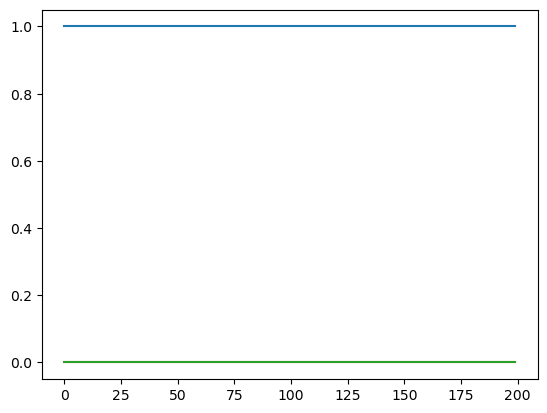

In [74]:
plt.plot(true_magnetic_field)

In [16]:
# Simulate IMU measurements
np.random.seed(42)
num_samples = 200
time = np.arange(0, num_samples)
dt = 0.01  # Time step

# Generate true motion
true_orientation = R.from_euler('zyx', np.vstack([np.sin(0.1 * time), np.cos(0.1 * time), np.zeros(num_samples)]).T).as_quat()
true_angular_velocity = np.vstack([np.zeros(num_samples), 0.1 * np.ones(num_samples), np.zeros(num_samples)]).T
true_magnetic_field = np.vstack([np.ones(num_samples), np.zeros(num_samples), np.zeros(num_samples)]).T

# Simulate sensor measurements (including noise)
acceleration = np.array([R.from_quat(true_orientation[i]).apply([0, 0, 9.8]) + np.random.normal(0, 0.1, 3) for i in range(num_samples)])
gyro_rate = true_angular_velocity + np.random.normal(0, 0.01, (num_samples, 3))
mag_field = true_magnetic_field + np.random.normal(0, 0.01, (num_samples, 3))


In [24]:
np.shape(mag_field)

(200, 3)

In [20]:
filtered_states = kalman_filter(acceleration, gyro_rate, mag_field, dt)

ValueError: operands could not be broadcast together with shapes (9,) (6,) 

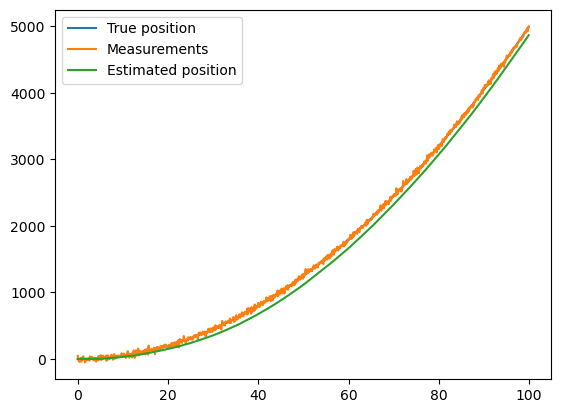

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Kalman filter class
class KalmanFilter(object):
    def __init__(self, dt, u, std_acc, std_meas):
        self.dt = dt
        self.u = u
        self.std_acc = std_acc
        self.A = np.matrix([[1, self.dt], [0, 1]])
        self.B = np.matrix([[(self.dt**2)/2], [self.dt]])
        self.H = np.matrix([[1, 0]])
        self.Q = np.matrix([[(self.dt**4)/4, (self.dt**3)/2], [(self.dt**3)/2, self.dt**2]]) * self.std_acc**2
        self.R = std_meas**2
        self.P = np.eye(self.A.shape[0])
        self.x = np.matrix([[0], [0]])

    def predict(self):
        self.x = np.dot(self.A, self.x) + np.dot(self.B, self.u)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        return self.x

    def update(self, z):
        y = z - np.dot(self.H, self.x)
        S = self.R + np.dot(self.H, np.dot(self.P, self.H.T))
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        self.P = np.dot((np.eye(self.A.shape[0]) - np.dot(K, self.H)), self.P)

# Define the main function
def main():
    dt = 0.1
    t = np.arange(0, 100, dt)
    real_track = 0.5 * t**2  # True position
    measurements = real_track + np.random.normal(0, 25, size=t.shape)  # Simulated position measurements

    kf = KalmanFilter(dt, u=0, std_acc=0.2, std_meas=25)

    estimated_pos = []
    for z in measurements:
        kf.predict()
        kf.update(z)
        estimated_pos.append(kf.x[0, 0])

    plt.plot(t, real_track, label='True position')
    plt.plot(t, measurements, label='Measurements')
    plt.plot(t, estimated_pos, label='Estimated position')
    plt.legend()
    plt.show()

# Run the main function
if __name__ == '__main__':
    main()

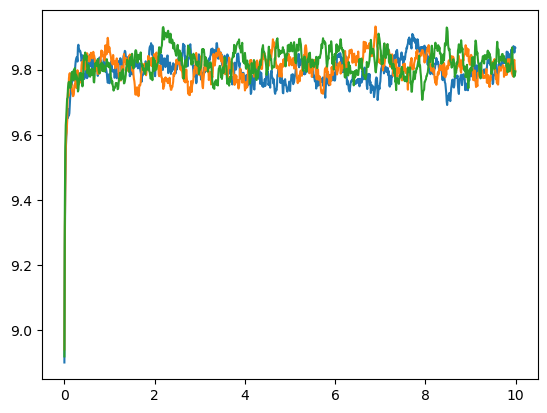

In [82]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Define the Kalman filter class
class KalmanFilter(object):
    def __init__(self, dt, std_acc, std_gyro, std_mag):
        # Initialize parameters
        self.dt = dt
        self.std_acc = std_acc
        self.std_gyro = std_gyro
        self.std_mag = std_mag

        # Initialize state matrices
        self.A = np.eye(3)  # State transition matrix
        self.H = np.eye(3)  # Measurement matrix
        self.Q = np.eye(3) * 0.001  # Process noise covariance
        self.R = np.eye(3) * 0.1  # Measurement noise covariance
        self.P = np.eye(3)  # Estimate error covariance

        # Initialize state vector
        self.x = np.zeros((3, 1))  # [roll, pitch, yaw]

    def predict(self, gyro):
        # Predict the state based on gyro measurements
        self.A[0, 1] = -gyro[2] * self.dt
        self.A[0, 2] = gyro[1] * self.dt
        self.A[1, 0] = gyro[2] * self.dt
        self.A[1, 2] = -gyro[0] * self.dt
        self.A[2, 0] = -gyro[1] * self.dt
        self.A[2, 1] = gyro[0] * self.dt

        # Update the state and error covariance
        self.x = np.dot(self.A, self.x)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q

    def update(self, acc, mag):
        # Update the state based on accelerometer and magnetometer measurements
        z = np.array([acc[0], acc[1], acc[2], mag[0], mag[1], mag[2]]).reshape((6, 1))
        #y = z - np.dot(self.H, self.x)
        y = z[:3] - np.dot(self.H, self.x)[:3]
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        self.P = np.dot((np.eye(3) - np.dot(K, self.H)), self.P)

        return self.x

# Generate simulated sensor measurements
def generate_measurements():
    dt = 0.01
    t = np.arange(0, 10, dt)
    gyro = np.random.normal(0, 0.1, size=(3, len(t)))
    acc = np.random.normal(9.81, 0.1, size=(3, len(t)))
    mag = np.random.normal(50, 5, size=(3, len(t)))

    return t, gyro, acc, mag

# Main function to run the example
def main():
    dt = 0.01
    kf = KalmanFilter(dt, std_acc=0.1, std_gyro=0.1, std_mag=5)

    t, gyro, acc, mag = generate_measurements()

    estimated_orientation = []
    for i in range(len(t)):
        kf.predict(gyro[:, i])
        orientation = kf.update(acc[:, i], mag[:, i])
        estimated_orientation.append(orientation)

    estimated_orientation = np.array(estimated_orientation).squeeze()
    plt.plot(t, estimated_orientation)
    plt.show()

# Run the main function
if __name__ == '__main__':
    main()